# Explore a spiral generator, one step at a time

Draw clean spiral points, hide them in more coordinates, and teach a small network to move Gaussian noise toward them. This notebook runs independently of the unfinished package exercises. Its reference functions illustrate their contracts. It does not complete the exercise files or reproduce the paper's training results.

Run cells in order with **Run All**. In Cursor or VS Code, select the repository's `.venv` Python kernel. Install the notebook dependencies from the repository root if needed:

```bash
python -m pip install -e './toy_experiment[notebook]'
```

Use the same Python environment for that command and the selected kernel. The notebook uses CPU float32 operations and a small training budget. Saved outputs show one checked run. After changing a control, restart the kernel and run all cells again.

## Route through the experiment

| Step | What you inspect | Expected behavior |
| --- | --- | --- |
| Draw data | A two-coordinate spiral | Every radius stays below 2 |
| Embed data | A fixed random plane in eight coordinates | Projection recovers the original points |
| Add noise | Inputs at different times | Perpendicular noise shrinks as time approaches 1 |
| Convert outputs | Clean, noise, and velocity oracles | All conversions recover the same velocity |
| Call the model | Five Linear layers and raw outputs | Shapes match, but initial predictions are untrained |
| Update once | Loss, gradients, and weight change | Gradients remain finite and weights change |
| Repeat a fixed batch | A loss curve | The network can learn this particular batch |
| Train with fresh noise | Training and held-out probe losses | Loss is noisy rather than decreasing at every step |
| Generate | A trajectory and final projected points | Finite outputs are required, spiral quality is not guaranteed |

See [DESIGN.md](DESIGN.md) for the full derivations and [TODO.md](TODO.md) for exercise checks.


In [1]:
%matplotlib inline
import copy
import math
import platform

import matplotlib
import matplotlib.pyplot as plt
import torch
from torch import nn
from IPython.display import Markdown, display

# Start with these controls. Restart and Run All after changing them.
D = 8                    # Observed coordinates: try 2, 8, 16, or 512.
HIDDEN = 256             # Keep fixed when comparing observed dimensions.
TRAIN_SIZE = 1024        # Smaller than the design's 8192-point baseline.
BATCH_SIZE = 64
FIXED_UPDATES = 60
FRESH_UPDATES = 300       # Demonstration budget, not a convergence claim.
SAMPLING_STEPS = 50
PREDICTION = "x"         # Try "eps" or "v" in a fresh full run.
SEED = 0
MARGIN = 0.001
LEARNING_RATE = 0.001

assert D >= 2 and PREDICTION in {"x", "eps", "v"}
assert 0 < MARGIN < 0.5
assert min(TRAIN_SIZE, BATCH_SIZE, FIXED_UPDATES, FRESH_UPDATES, SAMPLING_STEPS) > 0
assert BATCH_SIZE <= TRAIN_SIZE
# Limit this small CPU demonstration to one compute thread.
torch.set_num_threads(1)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True})
print({"Python": platform.python_version(), "PyTorch": torch.__version__,
       "Matplotlib": matplotlib.__version__, "device": "cpu", "dtype": "float32"})
print({"D": D, "hidden": HIDDEN, "prediction": PREDICTION,
       "fixed_updates": FIXED_UPDATES, "fresh_updates": FRESH_UPDATES})


{'Python': '3.9.6', 'PyTorch': '2.8.0', 'Matplotlib': '3.9.4', 'device': 'cpu', 'dtype': 'float32'}
{'D': 8, 'hidden': 256, 'prediction': 'x', 'fixed_updates': 60, 'fresh_updates': 300}


## 1. Draw the clean spiral

One uniform draw $u$ determines both radius and angle. With two turns and radius limit 2:

$$
r=2u,\qquad \phi=4\pi u,\qquad \hat x=(r\cos\phi,r\sin\phi),\qquad u\sim\mathrm{Uniform}[0,1).
$$

At $u=0.25$, the point is $(-0.5,0)$. Independent radius and angle draws would fill an area instead of tracing this curve. Uniform $u$ also gives denser points near the center than outside.

**Expected:** shape `(1024, 2)` with the default controls, float32 values, and maximum radius below 2. Equal seeds must give equal points. The scatter plot should show two spiral turns. These are clean construction samples, not model outputs.


shape: (1024, 2) maximum radius: 1.9997
first three clean rows: tensor([[ 0.9914, -0.0467],
        [-1.4963, -0.3488],
        [ 0.0784,  0.1586]])


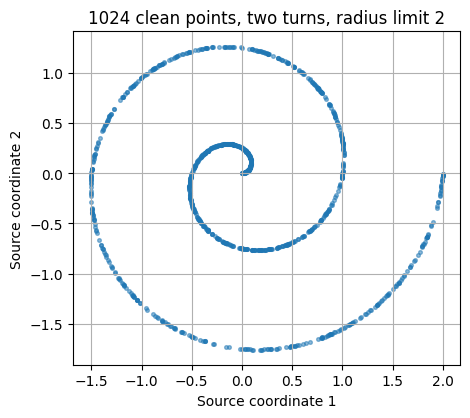

In [2]:
def spiral(count, *, generator, turns=2.0, radius=2.0):
    u = torch.rand(count, generator=generator, dtype=torch.float32)
    angle = 2 * math.pi * turns * u
    r = radius * u
    return torch.stack((r * torch.cos(angle), r * torch.sin(angle)), dim=1)

clean_2d = spiral(TRAIN_SIZE, generator=torch.Generator().manual_seed(SEED))
repeat = spiral(TRAIN_SIZE, generator=torch.Generator().manual_seed(SEED))
assert torch.equal(clean_2d, repeat)
assert clean_2d.shape == (TRAIN_SIZE, 2) and clean_2d.dtype == torch.float32
assert torch.isfinite(clean_2d).all()
radii = clean_2d.norm(dim=1)
assert radii.max() <= 2 + 1e-6
print("shape:", tuple(clean_2d.shape), "maximum radius:", round(radii.max().item(), 4))
print("first three clean rows:", clean_2d[:3])
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(*clean_2d.T.numpy(), s=7, alpha=0.5)
ax.set(xlabel="Source coordinate 1", ylabel="Source coordinate 2",
       title=f"{TRAIN_SIZE} clean points, two turns, radius limit 2")
ax.set_aspect("equal")
plt.show()


## 2. Embed the points without changing their geometry

Draw a fixed Gaussian matrix and retain its orthonormal QR factor $P$. The package stores samples as rows:

$$
P^{\mathsf T}P=I_2,\qquad x=\hat xP^{\mathsf T},\qquad xP=\hat x.
$$

Each observed sample has $D$ coordinates, but lies in the plane spanned by the columns of $P$. The model will not receive $P$. Evaluation will use it to recover source coordinates.

**Expected:** `P` has shape `(8, 2)` and observed data has shape `(1024, 8)` by default. Round-trip and length errors should stay within float32 rounding. The recovered spiral should match the source spiral.


P shape: (8, 2) observed shape: (1024, 8)
{'orthonormal_error': 5.960464477539063e-08, 'round_trip_error': 2.384185791015625e-07, 'length_error': 2.384185791015625e-07}


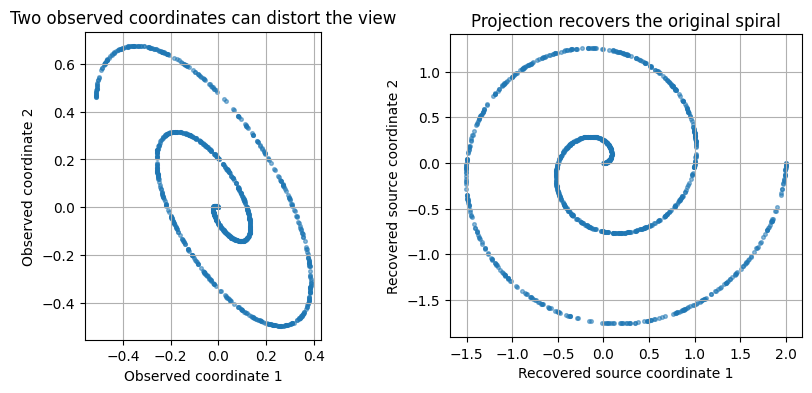

In [3]:
projection_generator = torch.Generator().manual_seed(123)
A = torch.randn(D, 2, generator=projection_generator)
P, _ = torch.linalg.qr(A, mode="reduced")
clean = clean_2d @ P.T
recovered = clean @ P
orthogonal_error = (P.T @ P - torch.eye(2)).abs().max().item()
round_trip_error = (recovered - clean_2d).abs().max().item()
length_error = (clean.norm(dim=1) - clean_2d.norm(dim=1)).abs().max().item()
assert orthogonal_error < 2e-5
assert round_trip_error < 2e-5 and length_error < 2e-5
print("P shape:", tuple(P.shape), "observed shape:", tuple(clean.shape))
print({"orthonormal_error": orthogonal_error, "round_trip_error": round_trip_error,
       "length_error": length_error})
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(*clean[:, :2].T.numpy(), s=7, alpha=0.5)
axes[0].set(xlabel="Observed coordinate 1", ylabel="Observed coordinate 2",
            title="Two observed coordinates can distort the view")
axes[1].scatter(*recovered.T.numpy(), s=7, alpha=0.5)
axes[1].set(xlabel="Recovered source coordinate 1", ylabel="Recovered source coordinate 2",
            title="Projection recovers the original spiral")
for ax in axes:
    ax.set_aspect("equal")
plt.show()


## 3. Follow a clean point through different noise levels

Noise has independent Gaussian values in every observed coordinate. The input and target velocity are

$$
z_t=tx+(1-t)\epsilon,\qquad v=x-\epsilon,\qquad \epsilon\sim\mathcal N(0,I_D).
$$

Use the same clean points and noise draw across panels. Only time changes. Projected noise remains visible within the plane. Perpendicular noise disappears from a two-coordinate plot, so measure it separately.

For $Q=PP^{\mathsf T}$, the expected squared perpendicular length is

$$
\mathbb E\lVert z_t(I-Q)\rVert_2^2=(1-t)^2(D-2).
$$

**Expected:** each input has shape `(1024, 8)` by default. At $D=8$, theoretical means at times 0.05, 0.5, and 0.95 are 5.415, 1.5, and 0.015. Empirical means vary with the finite noise draw. At $D=2$, this residual is zero apart from rounding.


t=0.05: measured perpendicular mean=5.42048; theoretical=5.41500
t=0.50: measured perpendicular mean=1.50152; theoretical=1.50000
t=0.95: measured perpendicular mean=0.01502; theoretical=0.01500


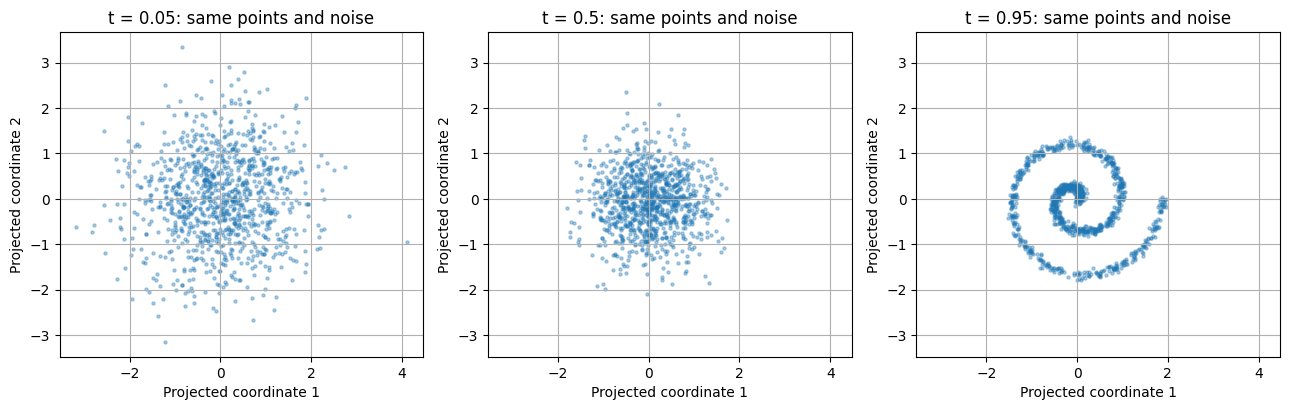

In [4]:
def perpendicular_squared(points, projection):
    residual = points - (points @ projection) @ projection.T
    return residual.square().sum(dim=1)

noise_view = torch.randn(clean.shape, generator=torch.Generator().manual_seed(SEED + 10))
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, time in zip(axes, (0.05, 0.5, 0.95)):
    noisy = time * clean + (1 - time) * noise_view
    projected = noisy @ P
    measured = perpendicular_squared(noisy, P).mean().item()
    expected = (1 - time)**2 * (D - 2)
    # An exact scaling check uses the same finite noise draw, not its expectation.
    actual_noise_mean = perpendicular_squared(noise_view, P).mean()
    torch.testing.assert_close(perpendicular_squared(noisy, P).mean(),
                               (1 - time)**2 * actual_noise_mean, atol=2e-5, rtol=2e-5)
    print(f"t={time:.2f}: measured perpendicular mean={measured:.5f}; theoretical={expected:.5f}")
    ax.scatter(*projected.T.numpy(), s=5, alpha=0.35)
    ax.set(xlabel="Projected coordinate 1", ylabel="Projected coordinate 2",
           title=f"t = {time}: same points and noise")
    ax.set_aspect("equal")
# One common view makes noise levels comparable; report clipped points if limiting axes later.
limits = [ax.axis() for ax in axes]
for ax in axes:
    ax.set_xlim(min(v[0] for v in limits), max(v[1] for v in limits))
    ax.set_ylim(min(v[2] for v in limits), max(v[3] for v in limits))
plt.tight_layout()
plt.show()


## 4. Check target conversions before using a model

A direct output can represent clean data, noise, or velocity. Convert each output to velocity before measuring loss:

$$
\hat v_x=\frac{\hat x-z_t}{1-t},\qquad \hat v_\epsilon=\frac{z_t-\hat\epsilon}{t},\qquad \hat v_v=\hat v.
$$

**Expected:** for clean value 2, noise −1, and time 0.25, the input is −0.25 and all three oracle outputs recover velocity 3. A two-coordinate loss check should return 2.5. These are exact arithmetic checks, not learned predictions.


In [5]:
def to_velocity(raw, z, t, prediction):
    assert raw.shape == z.shape and t.shape == (z.shape[0], 1)
    assert torch.all((t >= MARGIN) & (t <= 1 - MARGIN))
    if prediction == "x":
        return (raw - z) / (1 - t)
    if prediction == "eps":
        return (z - raw) / t
    if prediction == "v":
        return raw
    raise ValueError(f"Unknown prediction mode: {prediction}")

def velocity_loss(predicted, target):
    assert predicted.shape == target.shape
    return (predicted - target).square().mean()

example_x = torch.tensor([[2.0]])
example_noise = torch.tensor([[-1.0]])
example_t = torch.tensor([[0.25]])
example_z = example_t * example_x + (1 - example_t) * example_noise
example_v = example_x - example_noise
for mode, raw in (("x", example_x), ("eps", example_noise), ("v", example_v)):
    converted = to_velocity(raw, example_z, example_t, mode)
    torch.testing.assert_close(converted, example_v)
    print(f"{mode}: input={example_z.item()}, converted velocity={converted.item()}")
loss_check = velocity_loss(torch.tensor([[2.0, 0.0]]), torch.tensor([[1.0, -2.0]]))
assert loss_check.item() == 2.5
print("Hand-calculated mean squared loss:", loss_check.item())


x: input=-0.25, converted velocity=3.0
eps: input=-0.25, converted velocity=3.0
v: input=-0.25, converted velocity=3.0
Hand-calculated mean squared loss: 2.5


## 5. Construct the network and inspect one forward pass

The model concatenates time with the noisy coordinates. Four hidden layers use the rectified linear unit, or ReLU. The fifth Linear layer returns an unconstrained output:

$$
D+1\longrightarrow256\longrightarrow256\longrightarrow256\longrightarrow256\longrightarrow D.
$$

ReLU replaces negative values with zero. There is no projection input or input-to-output bypass. The chosen `PREDICTION` assigns meaning to the raw output outside the network.

**Expected:** five Linear layers, four ReLU layers, and `(64, 8)` raw outputs by default. At $D=8$, the parameter count is 201,992. All three output interpretations must have finite initial loss, but their losses need not match. No initial prediction should be mistaken for a learned clean point.


In [6]:
torch.manual_seed(SEED)
model = nn.Sequential(
    nn.Linear(D + 1, HIDDEN), nn.ReLU(),
    nn.Linear(HIDDEN, HIDDEN), nn.ReLU(),
    nn.Linear(HIDDEN, HIDDEN), nn.ReLU(),
    nn.Linear(HIDDEN, HIDDEN), nn.ReLU(),
    nn.Linear(HIDDEN, D),
)
initial_state = copy.deepcopy(model.state_dict())
parameter_count = sum(p.numel() for p in model.parameters())
assert sum(isinstance(layer, nn.Linear) for layer in model) == 5
assert parameter_count == 2 * D * HIDDEN + 5 * HIDDEN + 3 * HIDDEN**2 + D
print(model)
print("parameters:", parameter_count)

# One prepared batch remains fixed while inspecting forward, backward, and learning.
flow_generator = torch.Generator().manual_seed(SEED + 3)
fixed_x = clean[:BATCH_SIZE].clone()
fixed_t = torch.full((BATCH_SIZE, 1), 0.5)
fixed_noise = torch.randn(fixed_x.shape, generator=flow_generator)
fixed_z = fixed_t * fixed_x + (1 - fixed_t) * fixed_noise
fixed_v = fixed_x - fixed_noise
model_input = torch.cat((fixed_z, fixed_t), dim=1)
raw = model(model_input)
assert raw.shape == fixed_x.shape
print("input:", tuple(model_input.shape), "raw output:", tuple(raw.shape))
for mode in ("x", "eps", "v"):
    loss = velocity_loss(to_velocity(raw, fixed_z, fixed_t, mode), fixed_v)
    assert torch.isfinite(loss)
    print(f"Untrained raw output interpreted as {mode}: velocity loss={loss.item():.6f}")


Sequential(
  (0): Linear(in_features=9, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): ReLU()
  (6): Linear(in_features=256, out_features=256, bias=True)
  (7): ReLU()
  (8): Linear(in_features=256, out_features=8, bias=True)
)
parameters: 201992
input: (64, 9) raw output: (64, 8)
Untrained raw output interpreted as x: velocity loss=0.605078
Untrained raw output interpreted as eps: velocity loss=3.887700
Untrained raw output interpreted as v: velocity loss=1.133511


## 6. Inspect one training update

Clear old gradients, run the model, convert its output, compute loss, and call backward. Examine gradients before stepping the optimizer. Then measure loss on the same fixed batch again.

$$
L_v=\frac{1}{BD}\sum_{i=1}^{B}\lVert\hat v_i-v_i\rVert_2^2.
$$

**Expected:** finite loss and gradient norms for each Linear layer. At least one parameter must change. The loss after one update often decreases on this batch, but an arbitrary step is not guaranteed to improve it. Printed training loss describes the state before the update, while the second loss describes the state after it.


In [7]:
def predict_velocity(network, z, t, mode):
    raw = network(torch.cat((z, t), dim=1))
    return to_velocity(raw, z, t, mode)

def update(network, optimizer, z, t, target, mode):
    network.train()
    optimizer.zero_grad(set_to_none=True)
    loss = velocity_loss(predict_velocity(network, z, t, mode), target)
    assert torch.isfinite(loss), "Non-finite loss"
    loss.backward()
    for name, parameter in network.named_parameters():
        assert parameter.grad is not None, f"No gradient for {name}"
        assert torch.isfinite(parameter.grad).all(), f"Non-finite gradient for {name}"
    optimizer.step()
    return loss.detach().item()

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                             betas=(0.9, 0.95), weight_decay=0.0)
before = {name: p.detach().clone() for name, p in model.named_parameters()}
loss_before = update(model, optimizer, fixed_z, fixed_t, fixed_v, PREDICTION)
for name, parameter in model.named_parameters():
    if name.endswith("weight"):
        print(f"{name}: gradient norm={parameter.grad.norm().item():.6f}")
max_change = max((p.detach() - before[name]).abs().max().item()
                 for name, p in model.named_parameters())
with torch.no_grad():
    loss_after = velocity_loss(predict_velocity(model, fixed_z, fixed_t, PREDICTION), fixed_v).item()
assert max_change > 0
print({"loss_before_update": loss_before, "loss_after_update": loss_after,
       "maximum_parameter_change": max_change})


0.weight: gradient norm=0.009458
2.weight: gradient norm=0.060182
4.weight: gradient norm=0.062962
6.weight: gradient norm=0.071080
8.weight: gradient norm=0.090472
{'loss_before_update': 0.6050775051116943, 'loss_after_update': 0.5802634358406067, 'maximum_parameter_change': 0.0010000001639127731}


## 7. Learn this fixed batch before learning a distribution

Repeat updates using the same noisy input, times, and target. No random draw occurs within this loop. It checks whether the forward pass, conversion, gradients, and optimizer connect.

**Expected:** this small batch should become easier to fit over repeated updates. The plot contains one measurement after each completed update. A declining curve supports learning on this batch only. It does not establish generalization or sample quality.


Fixed batch: initial=0.605078, after 60 updates=0.005362


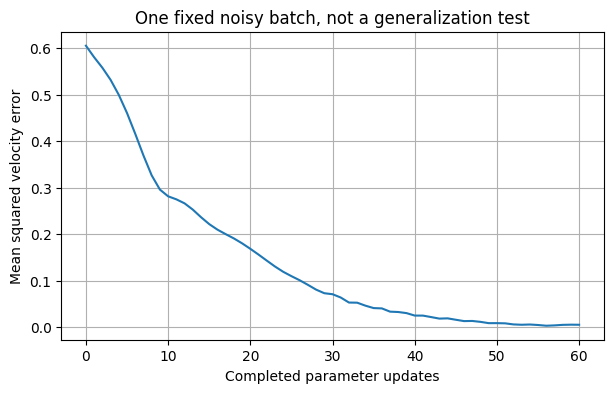

In [8]:
fixed_history = [loss_before, loss_after]
for _ in range(FIXED_UPDATES - 1):
    update(model, optimizer, fixed_z, fixed_t, fixed_v, PREDICTION)
    with torch.no_grad():
        value = velocity_loss(predict_velocity(model, fixed_z, fixed_t, PREDICTION), fixed_v)
    fixed_history.append(value.item())
print(f"Fixed batch: initial={fixed_history[0]:.6f}, after {FIXED_UPDATES} updates={fixed_history[-1]:.6f}")
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(len(fixed_history)), fixed_history)
ax.set(xlabel="Completed parameter updates", ylabel="Mean squared velocity error",
       title="One fixed noisy batch, not a generalization test")
plt.show()


## 8. Train with fresh time and noise draws

Reset the model to its original weights and create a new optimizer. The fixed-batch experiment must not give this training run a head start. Draw reusable clean points, but select new batches, times, and noise at every update.

The time rule is

$$
s\sim\mathcal N(-0.8,0.8^2),\qquad t=\min(1-\delta,\max(\delta,1/(1+e^{-s}))).
$$

A fixed probe uses independently drawn clean points, noise, and times. It never trains the model. Keeping that probe unchanged makes its before/after losses comparable. Its finite sample cannot establish population performance.

**Expected:** training losses fluctuate because each batch changes. Probe loss often improves, but neither curve must decrease at every update. Noise and clean conversions amplify errors near opposite endpoints. A short run, especially at large $D$, may not produce a recognizable spiral.


Probe loss: initial=0.489844, final=0.316938
Each training point uses a fresh batch; each probe point uses the same held-out inputs.


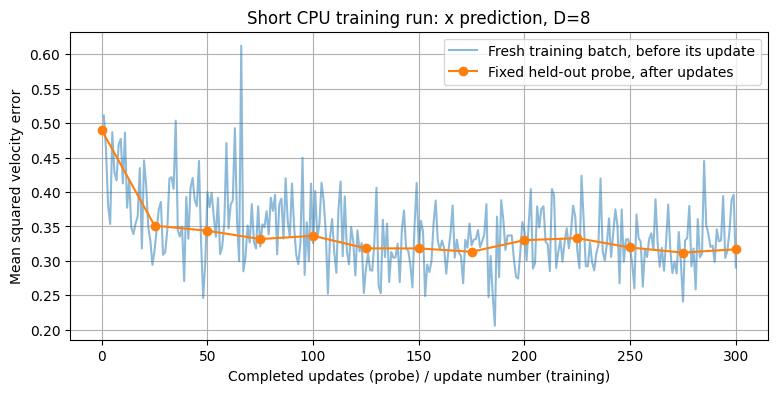

In [9]:
def draw_times(count, generator):
    s = -0.8 + 0.8 * torch.randn(count, 1, generator=generator)
    return torch.sigmoid(s).clamp(MARGIN, 1 - MARGIN)

model.load_state_dict(initial_state)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                             betas=(0.9, 0.95), weight_decay=0.0)
index_generator = torch.Generator().manual_seed(SEED + 2)
training_generator = torch.Generator().manual_seed(SEED + 3)
probe_generator = torch.Generator().manual_seed(SEED + 101)
probe_x = spiral(256, generator=probe_generator) @ P.T
probe_t = draw_times(len(probe_x), probe_generator)
probe_noise = torch.randn(probe_x.shape, generator=probe_generator)
probe_z = probe_t * probe_x + (1 - probe_t) * probe_noise
probe_v = probe_x - probe_noise

def probe_loss():
    with torch.no_grad():
        return velocity_loss(predict_velocity(model, probe_z, probe_t, PREDICTION), probe_v).item()

training_history = []
probe_steps, probe_history = [0], [probe_loss()]
for step in range(1, FRESH_UPDATES + 1):
    # Sampling with replacement is an explicit notebook simplification of the design's loader.
    indices = torch.randint(TRAIN_SIZE, (BATCH_SIZE,), generator=index_generator)
    batch_x = clean[indices]
    batch_t = draw_times(BATCH_SIZE, training_generator)
    batch_noise = torch.randn(batch_x.shape, generator=training_generator)
    batch_z = batch_t * batch_x + (1 - batch_t) * batch_noise
    batch_v = batch_x - batch_noise
    training_history.append(update(model, optimizer, batch_z, batch_t, batch_v, PREDICTION))
    if step % 25 == 0 or step == FRESH_UPDATES:
        probe_steps.append(step)
        probe_history.append(probe_loss())
assert len(training_history) == FRESH_UPDATES
print(f"Probe loss: initial={probe_history[0]:.6f}, final={probe_history[-1]:.6f}")
print("Each training point uses a fresh batch; each probe point uses the same held-out inputs.")
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, FRESH_UPDATES + 1), training_history, alpha=0.5,
        label="Fresh training batch, before its update")
ax.plot(probe_steps, probe_history, marker="o", label="Fixed held-out probe, after updates")
ax.set(xlabel="Completed updates (probe) / update number (training)",
       ylabel="Mean squared velocity error", title=f"Short CPU training run: {PREDICTION} prediction, D={D}")
ax.legend()
plt.show()


## 9. Examine predictions at a fixed noise level

Use new evaluation points with $t=0.5$. Convert the model's velocity prediction into an implied clean point:

$$
\hat x=z_t+(1-t)\hat v.
$$

For clean prediction, this recovers the raw output exactly. For the other modes, it gives a comparable clean estimate. Connect the first 32 projected input points to their estimates.

**Expected:** some estimates may move toward the clean distribution after training. The ideal estimate is a conditional average, so it need not lie on the spiral. The printed losses and residuals describe this saved finite evaluation batch. A two-coordinate plot cannot reveal perpendicular errors.


{'velocity_loss_at_time_0.5': 0.375271737575531, 'mean_squared_clean_plane_residual': 0.000285783113213256}


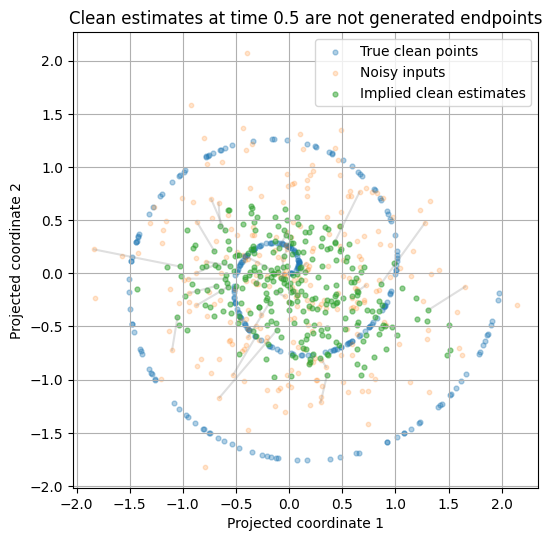

In [10]:
evaluation_generator = torch.Generator().manual_seed(SEED + 202)
evaluation_x = spiral(256, generator=evaluation_generator) @ P.T
evaluation_noise = torch.randn(evaluation_x.shape, generator=evaluation_generator)
evaluation_t = torch.full((256, 1), 0.5)
evaluation_z = evaluation_t * evaluation_x + (1 - evaluation_t) * evaluation_noise
model.eval()
with torch.no_grad():
    evaluation_velocity = predict_velocity(model, evaluation_z, evaluation_t, PREDICTION)
    implied_clean = evaluation_z + (1 - evaluation_t) * evaluation_velocity
    evaluation_loss = velocity_loss(evaluation_velocity, evaluation_x - evaluation_noise).item()
print({"velocity_loss_at_time_0.5": evaluation_loss,
       "mean_squared_clean_plane_residual": perpendicular_squared(implied_clean, P).mean().item()})
fig, ax = plt.subplots(figsize=(6, 6))
source_view = evaluation_z @ P
estimate_view = implied_clean @ P
ax.scatter(*(evaluation_x @ P).T.numpy(), s=12, alpha=0.35, label="True clean points")
ax.scatter(*source_view.T.numpy(), s=10, alpha=0.2, label="Noisy inputs")
ax.scatter(*estimate_view.T.numpy(), s=12, alpha=0.5, label="Implied clean estimates")
for start, end in zip(source_view[:32], estimate_view[:32]):
    ax.plot([start[0], end[0]], [start[1], end[1]], color="gray", alpha=0.25)
ax.set(xlabel="Projected coordinate 1", ylabel="Projected coordinate 2",
       title="Clean estimates at time 0.5 are not generated endpoints")
ax.set_aspect("equal")
ax.legend()
plt.show()


## 10. Generate points by integrating the learned field

Draw Gaussian initial states once. Freeze the weights and apply Heun's method at each interval:

$$
\tilde z_{k+1}=z_k+h\hat v(z_k,t_k),\qquad
z_{k+1}=z_k+\frac{h}{2}\left[\hat v(z_k,t_k)+\hat v(\tilde z_{k+1},t_{k+1})\right].
$$

The second velocity uses the proposal and next time. The update still starts from the original state. Convert each model output before averaging velocities. Do not draw fresh noise within the solver.

**Expected:** 51 stored states for 50 intervals, each with 256 observed points by default. Returned states must be finite and detached. At a short training budget, points may cluster, spread, or miss spiral turns. Those outcomes are useful observations rather than failed shape checks.

Starting with pure noise at $\delta=0.001$ approximates the true initial interpolation. Stopping at $1-\delta$ leaves another endpoint approximation. This notebook uses the same interior policy as the design.


In [11]:
# Test solver order on v(z,t)=z before sampling the trained model.
h = 0.1
proposal = 1 + h * 1
heun_check = 1 + h * (1 + proposal) / 2
assert abs(heun_check - 1.105) < 1e-12
print(f"Known field: Euler={proposal}, Heun={heun_check}, exact={math.exp(h):.6f}")

sampling_generator = torch.Generator().manual_seed(SEED + 303)
state = torch.randn(256, D, generator=sampling_generator)
time_grid = torch.linspace(MARGIN, 1 - MARGIN, SAMPLING_STEPS + 1)
trajectory = [state.clone()]
sampling_diagnostics = []
previous_training_flag = model.training
model.eval()
try:
    with torch.inference_mode():
        for time, next_time in zip(time_grid[:-1], time_grid[1:]):
            t = time.expand(len(state), 1)
            t_next = next_time.expand(len(state), 1)
            interval = next_time - time
            current_velocity = predict_velocity(model, state, t, PREDICTION)
            proposal = state + interval * current_velocity
            next_velocity = predict_velocity(model, proposal, t_next, PREDICTION)
            step_change = interval * (current_velocity + next_velocity) / 2
            sampling_diagnostics.append({
                "start_time": round(time.item(), 5),
                "end_time": round(next_time.item(), 5),
                "mean_start_velocity_length": current_velocity.norm(dim=1).mean().item(),
                "mean_proposal_velocity_length": next_velocity.norm(dim=1).mean().item(),
                "mean_step_length": step_change.norm(dim=1).mean().item(),
            })
            state = state + step_change
            assert torch.isfinite(state).all(), "Non-finite integration state"
            trajectory.append(state.clone())
finally:
    model.train(previous_training_flag)
assert len(trajectory) == SAMPLING_STEPS + 1
assert trajectory[-1].shape == (256, D) and trajectory[-1].grad_fn is None
print("Stored states:", len(trajectory), "final shape:", tuple(trajectory[-1].shape))

print("Last three intervals (lengths use all observed coordinates):")
for record in sampling_diagnostics[-3:]:
    print({key: round(value, 6) for key, value in record.items()})

Known field: Euler=1.1, Heun=1.105, exact=1.105171
Stored states: 51 final shape: (256, 8)
Last three intervals (lengths use all observed coordinates):
{'start_time': 0.93912, 'end_time': 0.95908, 'mean_start_velocity_length': 6.397447, 'mean_proposal_velocity_length': 9.124231, 'mean_step_length': 0.154559}
{'start_time': 0.95908, 'end_time': 0.97904, 'mean_start_velocity_length': 9.069676, 'mean_proposal_velocity_length': 16.498926, 'mean_step_length': 0.254459}
{'start_time': 0.97904, 'end_time': 0.999, 'mean_start_velocity_length': 15.93322, 'mean_proposal_velocity_length': 266.200073, 'mean_step_length': 2.811689}


## 11. Read the trajectory and check what projection hides

Each scatter point is one integrated state projected into the source plane. The four panels follow the same 256 states. The residual curve measures their mean squared distance from that plane:

$$
R_k=\frac{1}{N}\sum_{i=1}^{N}\lVert z_{k,i}-(z_{k,i}P)P^{\mathsf T}\rVert_2^2.
$$

**Expected:** projection may show progress toward the spiral. Inspect the residual too. A low residual does not establish a correct spiral, and a plausible spiral can hide perpendicular error. The printed numbers come directly from this trajectory. At $D=2$, the residual cannot distinguish sample quality because the plane is the entire observed space.


If the final scatter panel suddenly spreads, inspect the last three interval records above. The clean conversion divides by a denominator that reaches 0.001 at the endpoint. It can amplify prediction errors even when the training loss decreased. The proposal velocity and step length show whether a large final update occurred. They do not separate prediction error from numerical integration error.


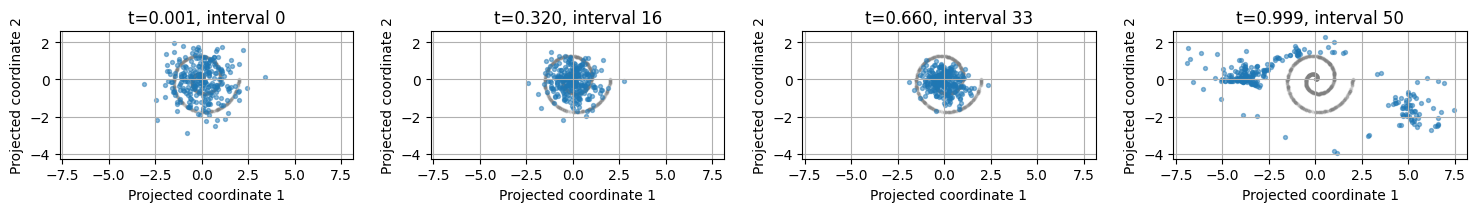

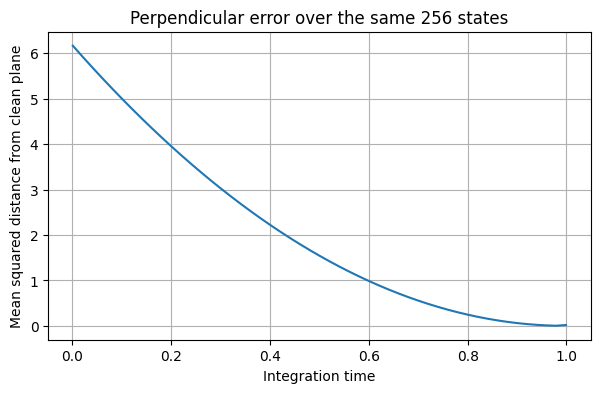

{'initial_plane_residual': 6.167641639709473, 'final_plane_residual': 0.01932598277926445, 'largest_absolute_final_coordinate': 3.9740078449249268}


- Each trajectory panel shows the same 256 states at its labelled time, projected into two coordinates. The last panel follows 50 intervals. All plotted coordinates are in data units.
- Each residual-curve point averages squared perpendicular lengths over those 256 states. It starts at 6.167642 and ends at 0.019326 squared coordinate units.
- These plots show this short run. They cannot establish a correct spiral distribution or identify the cause of solver error.

In [12]:
checkpoints = [0, SAMPLING_STEPS // 3, 2 * SAMPLING_STEPS // 3, SAMPLING_STEPS]
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
projected_states = [points @ P for points in trajectory]
for ax, index in zip(axes, checkpoints):
    projected = projected_states[index]
    ax.scatter(*clean_2d.T.numpy(), s=3, alpha=0.12, color="gray", label="Reference")
    ax.scatter(*projected.T.numpy(), s=8, alpha=0.5, label="Integrated states")
    ax.set(xlabel="Projected coordinate 1", ylabel="Projected coordinate 2",
           title=f"t={time_grid[index].item():.3f}, interval {index}")
    ax.set_aspect("equal")
limits = [ax.axis() for ax in axes]
for ax in axes:
    ax.set_xlim(min(v[0] for v in limits), max(v[1] for v in limits))
    ax.set_ylim(min(v[2] for v in limits), max(v[3] for v in limits))
plt.tight_layout()
plt.show()

residual_history = [perpendicular_squared(points, P).mean().item() for points in trajectory]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(time_grid.numpy(), residual_history)
ax.set(xlabel="Integration time", ylabel="Mean squared distance from clean plane",
       title="Perpendicular error over the same 256 states")
plt.show()
print({"initial_plane_residual": residual_history[0],
       "final_plane_residual": residual_history[-1],
       "largest_absolute_final_coordinate": trajectory[-1].abs().max().item()})


display(Markdown(
    f"- Each trajectory panel shows the same 256 states at its labelled time, projected into two coordinates. "
    f"The last panel follows {SAMPLING_STEPS} intervals. All plotted coordinates are in data units.\n"
    f"- Each residual-curve point averages squared perpendicular lengths over those 256 states. "
    f"It starts at {residual_history[0]:.6f} and ends at {residual_history[-1]:.6f} squared coordinate units.\n"
    "- These plots show this short run. They cannot establish a correct spiral distribution or identify the cause of solver error."
))


## 12. Interpret this run before changing a control

The oracle checks establish the conversions and loss arithmetic. Finite gradients and changed weights establish that an update occurred. The fixed-batch curve checks learning on one batch. The independent probe checks one finite set of unseen inputs. The trajectory shows what the short trained model generated. None of these observations alone reproduces the paper's comparison.

The notebook differs from the baseline design in sample count, batch size, update budget, and batch selection. It samples clean rows with replacement rather than traversing a shuffled loader. Keep those differences visible when reporting results.

For the next experiment, change only `PREDICTION` from `x` to `eps`. Restart the kernel and run all cells. Keep dimension, projection seed, architecture, data, noise streams, learning rate, and update counts unchanged. Compare the probe losses, projected endpoints, and plane residuals. All shape, oracle, and finite-value checks must still pass. A target need not win for the implementation to pass.

If a finite-value check fails, examine the printed loss, gradients, time margin, and first failing interval before changing the training budget. If checks pass but samples look poor, increase only `FRESH_UPDATES` in a separate recorded run. Compare the same probe and sampling seeds. Do not treat fixed-batch memorization as a reason to expect good generated samples.
